# 유방암 데이터셋을 활용한 이진 분류 다층 퍼셉트론 모델

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [2]:
cancer = load_breast_cancer()

cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [3]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [4]:
cancer.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [6]:
df = pd.DataFrame(
    data=cancer.data,
    columns=cancer.feature_names,
)
df['class'] = cancer.target

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [22]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.818923,-1.367076,-0.790130,-0.778279,1.330218,0.165189,-0.531130,-0.032711,-0.166117,-0.302819,-0.242731,0.210858,-0.494252,-0.313848,1.389707,0.641186,-0.272138,1.345406,-0.585171,-0.085555,-0.920898,-1.608655,-0.936138,-0.807961,0.134963,-0.451647,-0.867777,-0.425920,-1.295462,-0.877534
1,0.096514,-0.660981,0.102787,-0.023850,0.048618,0.170724,-0.114230,-0.179666,0.341386,0.180727,-0.204245,-0.783491,-0.079561,-0.180817,-0.799787,0.371414,0.236529,0.166383,-0.197232,-0.114138,0.085720,-0.705892,0.130031,-0.027544,-0.171460,0.478321,0.468736,0.392500,0.209024,0.181087
2,-0.629422,-1.922985,-0.657565,-0.607914,-0.547743,-0.963735,-0.781987,-0.802108,-0.778001,-1.058004,-0.552776,-0.306815,-0.595666,-0.482828,-0.277030,-0.749501,-0.521702,-0.911069,-1.225999,-0.742139,-0.522489,-0.921360,-0.596443,-0.524488,0.164345,-0.599937,-0.568321,-0.682741,-0.729104,-0.621968
3,-0.562367,-0.326987,-0.566795,-0.570840,-0.401875,-0.484708,-0.743660,-0.871097,-1.271107,-0.001314,-0.670751,-0.054927,-0.581106,-0.544420,-0.690525,-0.469424,-0.515240,-1.020643,-0.751998,-0.741725,-0.619972,0.294383,-0.560059,-0.601235,-0.532451,-0.177280,-0.519268,-0.858297,-0.814532,-0.372283
4,1.213115,0.110120,1.177244,1.149576,-0.146776,0.080307,0.289194,0.635125,-0.083333,-0.772143,0.146804,-0.778974,0.172969,0.317648,-0.885823,-0.641592,-0.251521,-0.166749,-0.864540,-0.608751,1.401741,0.261355,1.408088,1.328571,0.449780,0.001029,0.482156,1.159261,0.224844,-0.030637


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [8]:
data = torch.from_numpy(df.values).float()

data.shape

torch.Size([569, 31])

In [13]:
x = data[:, :-1]
y = data[:, -1:]

print(x.shape, y.shape)

torch.Size([569, 30]) torch.Size([569, 1])


In [14]:
ratio = [0.6, 0.2, 0.2]

In [16]:
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt

cnts = [train_cnt, valid_cnt, test_cnt]

print(f'train/valid/test dataset count: {train_cnt}, {valid_cnt}, {test_cnt}')

train/valid/test dataset count: 341, 113, 115


In [19]:
indices = torch.randperm(data.size(0))

x = torch.index_select(x, dim=0, index=indices)
y = torch.index_select(y, dim=0, index=indices)

x = x.split(cnts, dim=0)
y = y.split(cnts, dim=0)

for x_i, y_i in zip(x, y):
    print(x_i.shape, y_i.shape)

torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])


In [23]:
scaler = StandardScaler()
scaler.fit(x[0].numpy())

x = [
    torch.from_numpy(scaler.transform(x[0].numpy())).float(),
    torch.from_numpy(scaler.transform(x[1].numpy())).float(),
    torch.from_numpy(scaler.transform(x[2].numpy())).float()
]

df = pd.DataFrame(x[0].numpy(), columns=cancer.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.818923,-1.367076,-0.790130,-0.778279,1.330218,0.165189,-0.531130,-0.032711,-0.166117,-0.302819,-0.242731,0.210858,-0.494252,-0.313848,1.389707,0.641185,-0.272138,1.345407,-0.585171,-0.085555,-0.920898,-1.608655,-0.936138,-0.807961,0.134962,-0.451647,-0.867777,-0.425920,-1.295462,-0.877534
1,0.096514,-0.660981,0.102787,-0.023850,0.048618,0.170724,-0.114230,-0.179666,0.341386,0.180727,-0.204245,-0.783491,-0.079561,-0.180817,-0.799787,0.371414,0.236529,0.166383,-0.197232,-0.114138,0.085720,-0.705892,0.130031,-0.027544,-0.171460,0.478321,0.468736,0.392500,0.209024,0.181087
2,-0.629422,-1.922985,-0.657565,-0.607914,-0.547743,-0.963735,-0.781987,-0.802108,-0.778001,-1.058003,-0.552776,-0.306815,-0.595666,-0.482828,-0.277030,-0.749501,-0.521702,-0.911069,-1.225999,-0.742139,-0.522489,-0.921360,-0.596443,-0.524488,0.164345,-0.599937,-0.568321,-0.682741,-0.729104,-0.621968
3,-0.562367,-0.326987,-0.566795,-0.570840,-0.401876,-0.484708,-0.743660,-0.871097,-1.271107,-0.001314,-0.670751,-0.054927,-0.581106,-0.544420,-0.690525,-0.469424,-0.515240,-1.020643,-0.751998,-0.741725,-0.619972,0.294383,-0.560058,-0.601235,-0.532451,-0.177280,-0.519268,-0.858296,-0.814532,-0.372283
4,1.213115,0.110120,1.177244,1.149576,-0.146777,0.080307,0.289194,0.635125,-0.083333,-0.772143,0.146804,-0.778974,0.172969,0.317648,-0.885823,-0.641592,-0.251521,-0.166749,-0.864540,-0.608751,1.401741,0.261355,1.408088,1.328571,0.449780,0.001029,0.482156,1.159261,0.224844,-0.030637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,-0.367035,-0.842548,-0.372591,-0.419013,-0.433763,-0.405178,-0.382767,-0.473319,-0.403672,-0.528947,-0.920729,-1.275280,-0.823595,-0.650204,-0.702956,-0.390614,0.075897,-0.498247,-0.557367,-0.563184,-0.461033,-1.045608,-0.425832,-0.494773,-0.037138,0.021442,0.339624,-0.252437,0.134670,-0.333253
337,2.192692,0.625681,2.224258,2.229433,1.350572,1.920021,2.369987,2.743271,1.241215,0.456632,0.785237,-0.522396,0.663972,0.937697,-0.591077,0.779405,0.506710,0.239868,0.030500,0.157195,2.111672,0.431213,1.982908,2.194486,0.701634,1.886780,1.994936,1.884575,1.435077,0.879350
338,-0.973440,-1.012908,-0.990245,-0.865079,-1.279795,-0.982741,-0.825878,-1.060753,-1.505063,-0.848941,-0.551697,0.030193,-0.516844,-0.510533,-0.155337,-0.399707,-0.324144,-0.946995,-0.464685,-0.533772,-0.914541,-0.830140,-0.897612,-0.794836,-1.086530,-0.811266,-0.817520,-1.195346,-0.982225,-0.885554
339,-0.081325,0.955192,-0.006558,-0.151550,2.408960,1.331386,0.822065,1.090607,1.561554,1.615721,0.571587,1.230569,0.538962,0.290401,0.589543,0.404757,0.012506,0.244767,-0.031729,0.355206,0.621877,2.493099,0.652873,0.502761,3.740675,1.581794,0.881060,1.279160,2.390607,1.301729


4. 모델 & 옵티마이저 구성
- 입력 특성 x[0].size(-1) => 30
- 은닉층 25 -> 20 -> 15 -> 5 노드로 점차 축소하는 방식
- 각 은닉층 사이사이에 Leaky ReLU 함수 적용
- 출력층 y[0].size(-1) -> 1개 노드
- 출력층 활성화함수 Sigmoid -> 0 ~ 1 이진 분류 확률값 출력

In [53]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25),
    nn.LeakyReLU(),

    nn.Linear(25, 20),
    nn.LeakyReLU(),

    nn.Linear(20, 15),
    nn.LeakyReLU(),

    nn.Linear(15, 5),
    nn.LeakyReLU(),

    nn.Linear(5, y[0].size(-1)),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=30, out_features=25, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=25, out_features=20, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=20, out_features=15, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=15, out_features=5, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=5, out_features=1, bias=True)
  (9): Sigmoid()
)

In [54]:
# Adam 계열 최적화함수: 학습률 자동 조절하는 대표 옵티마이저
optimizer = optim.Adam(model.parameters())

5. 학습

In [55]:
n_epochs = 10000
batch_size = 32
print_interval = 100
early_stop = 1000

In [56]:
from copy import deepcopy

lowest_loss = np.inf
best_model = None
lowest_epoch = np.inf

In [57]:
train_history, valid_history = [], []

for i in range(n_epochs):
    indices = torch.randperm(x[0].size(0))

    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)

    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)

    train_loss, valid_loss = 0, 0
    y_hat = []

    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = F.binary_cross_entropy(y_hat_i, y_i)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += float(loss.detach())

    train_loss = train_loss / len(x_)

    with torch.no_grad():
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)

        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = F.binary_cross_entropy(y_hat_i, y_i)

            valid_loss += float(loss.detach())

            y_hat += [y_hat_i]

    valid_loss = valid_loss / len(x_)

    train_history += [train_loss]
    valid_history += [valid_loss]

    if (i+1) % print_interval == 0:
        print(f'Epoch {i+1}: Train loss = {train_loss}, Valid loss = {valid_loss}, Lowest loss = {lowest_loss}')
    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i

        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop <= i + 1:
            print(f'{early_stop} epoch 동안 향상된 기록 없음')
            break

print(f'최고 검증 성능 epoch {lowest_epoch + 1}, 최저 손실: {lowest_loss:.4e}')
model.load_state_dict(best_model)

Epoch 100: Train loss = 0.007487760803831572, Valid loss = 0.11233741892203852, Lowest loss = 0.07410299152252264
Epoch 200: Train loss = 0.002521559466274616, Valid loss = 0.1992971057847076, Lowest loss = 0.07410299152252264
Epoch 300: Train loss = 0.0007066455521980556, Valid loss = 0.3069126009941101, Lowest loss = 0.07410299152252264
Epoch 400: Train loss = 0.00023017410783474836, Valid loss = 0.41223105788230896, Lowest loss = 0.07410299152252264
Epoch 500: Train loss = 7.69952603729384e-05, Valid loss = 0.5143577605485916, Lowest loss = 0.07410299152252264
Epoch 600: Train loss = 2.7109920921318463e-05, Valid loss = 0.6061419248580933, Lowest loss = 0.07410299152252264
Epoch 700: Train loss = 1.039351156318891e-05, Valid loss = 0.6855304837226868, Lowest loss = 0.07410299152252264
Epoch 800: Train loss = 4.325602242776875e-06, Valid loss = 0.7546893656253815, Lowest loss = 0.07410299152252264
Epoch 900: Train loss = 1.879354612894681e-06, Valid loss = 0.8174169361591339, Lowest 

<All keys matched successfully>

valid_loss += float(loss)   # Tensor -> float (메모리 누수 방지)

loss 는 Tensor.autograd 그래프를 가짐  
train_loss 또는 valid_loss가 더해질 때마다 이전 loss 연산 그래프를 함께 참조 -> CPU/GPU 메모리 공간 차지  
float 형태로 바꿔 숫자만 실수형으로 가져와 저장하면 계산 그래프 안 그림

6. 손실 기록 또는 손실 변화 이력 그래프

In [59]:
print(type(train_history[0]))
print(type(valid_history[0]))

<class 'float'>
<class 'float'>


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

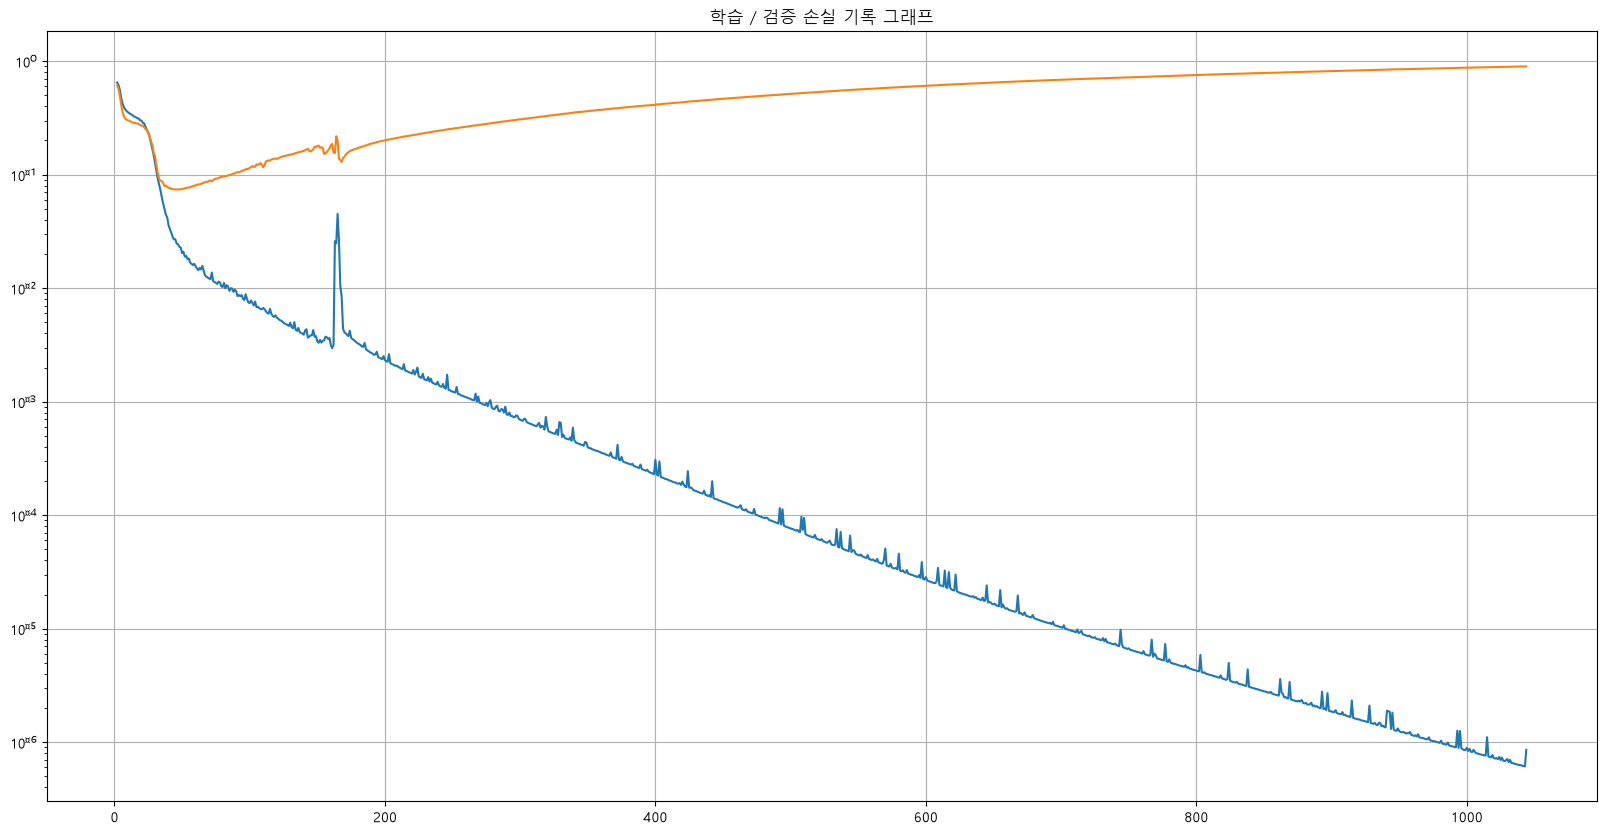

In [65]:
import warnings
warnings.filterwarnings('ignore')


plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plot_from = 2
plt.figure(figsize=(20, 10))
plt.grid(True)
plt.title('학습 / 검증 손실 기록 그래프')
plt.plot(
    range(plot_from, len(train_history)), train_history[plot_from:],
    range(plot_from, len(valid_history)), valid_history[plot_from:],
)
plt.yscale('log')
plt.show()

In [69]:
test_loss = 0
y_hat = []

with torch.no_grad():
    x_ = x[2].split(batch_size, dim=0)
    y_ = y[2].split(batch_size, dim=0)

    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = F.binary_cross_entropy(y_hat_i, y_i)

        test_loss += float(loss.detach())

        y_hat += [y_hat_i]

test_loss = test_loss / len(x_)
y_hat = torch.cat(y_hat, dim=0)

print(f'Test loss: {round(test_loss, 4)}')

Test loss: 0.0591


In [76]:
correct_cnt = (y[2] == (y_hat > 0.5)).sum()
total_cnt = float(y[2].size(0))

print(f'테스트 정확도: {correct_cnt / total_cnt * 100:.2f} %')

테스트 정확도: 96.52 %


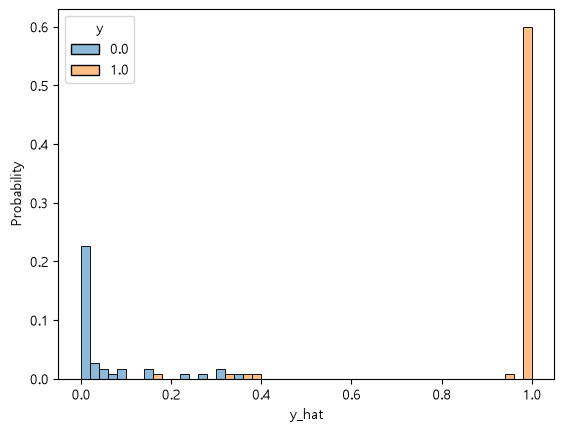

In [81]:
df = pd.DataFrame(
    torch.cat([y[2], y_hat], dim=1).detach().numpy(),
    columns=['y', 'y_hat']
)

sns.histplot(
    df, x='y_hat', hue='y', bins=50, stat='probability'
)

plt.show()

In [82]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df.values[:, 0],
    df.values[:, 1]
)

0.998022412656559

roc: 1 -> 완벽한 분류 / 0.5 -> 랜덤 추측 수준